# ESPIRiT

In [420]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from skimage.transform import resize
from skimage.data import shepp_logan_phantom
from sigpy.mri.sim import birdcage_maps
from tqdm import tqdm
import pywt, ptwt
import torch.nn.functional as F
import sigpy.mri

In [421]:
def init_phantom(resolution):
    image = shepp_logan_phantom().astype(np.float32)  # Shape format (H,W)
    image = resize(image, resolution, anti_aliasing=True)
    image = torch.tensor(image, dtype=torch.float)
    image = (image + 1j * torch.zeros_like(image))
    return image

def fft2c(image):
    image = torch.fft.ifftshift(image, dim=(-2, -1))
    kspace = torch.fft.fft2(image, dim=(-2, -1))
    kspace = torch.fft.fftshift(kspace, dim=(-2, -1))
    return kspace

def ifft2c(kspace):
    kspace = torch.fft.ifftshift(kspace, dim=(-2, -1))
    image = torch.fft.ifft2(kspace, dim=(-2, -1))
    image = torch.fft.fftshift(image, dim=(-2, -1))
    return image

def generate_sampling_mask(size, sample_fraction=0.5, sampling_scheme='variable-density', sampling_dim_option='1D'):

    num_rows, num_cols = size
    mask = np.zeros((num_rows, num_cols))
    
    if sampling_dim_option == '1D':

        if sampling_scheme == 'uniform':
            pmf = None
        
        elif sampling_scheme == 'variable-density':

            center_fraction = 0.25
            assert sample_fraction > center_fraction

            num_center_cols = int(center_fraction * num_cols)
            center_cols_range = (num_cols // 2 - num_center_cols // 2,  num_cols // 2 + num_center_cols // 2)
            mask[:, center_cols_range[0] : center_cols_range[1]] = 1
            
            pmf = np.ones(num_cols)
            pmf[center_cols_range[0] : center_cols_range[1]] = 0
            pmf = pmf / pmf.sum()
            
            sample_fraction = sample_fraction - center_fraction

        num_sample_lines = int(sample_fraction * num_cols)
        sampled_lines = np.random.choice(np.arange(num_cols), size=num_sample_lines, replace=False, p=pmf)        
        mask[:, sampled_lines] = 1

    elif sampling_dim_option == '2D':

        if sampling_scheme == 'uniform':
            pmf = None
        
        elif sampling_scheme == 'variable-density':
            # TODO
            pass
        
        grid_i, grid_j = np.meshgrid(np.arange(num_rows), np.arange(num_cols), indexing='ij')
        kspace_coords = np.stack((grid_i.flatten(), grid_j.flatten()), dim=1)
        num_samples = int(sample_fraction * (num_rows * num_cols))
        idxs = np.random.choice(np.arange(num_rows * num_cols), size=num_samples, replace=False, p=pmf)
        sampled_coords = kspace_coords[idxs]
        mask[sampled_coords[:, 0], sampled_coords[:, 1]] = 1

    return torch.tensor(mask.astype(bool))

def rss_combine(coil_images):
    return torch.sqrt(torch.sum(coil_images ** 2, dim=0))

def imshow(ndarray, ax=None, title=''):
    show = False
    if ax is None:
        show = True
        ax = plt.gca()
    ax.imshow(torch.squeeze(ndarray), cmap='gray')
    ax.set_axis_off()
    ax.set_title(title)
    if show: plt.show()

### Load data

In [422]:
# Settings

SIZE = 128
NUM_COILS = 8
ACCELERATION = 2

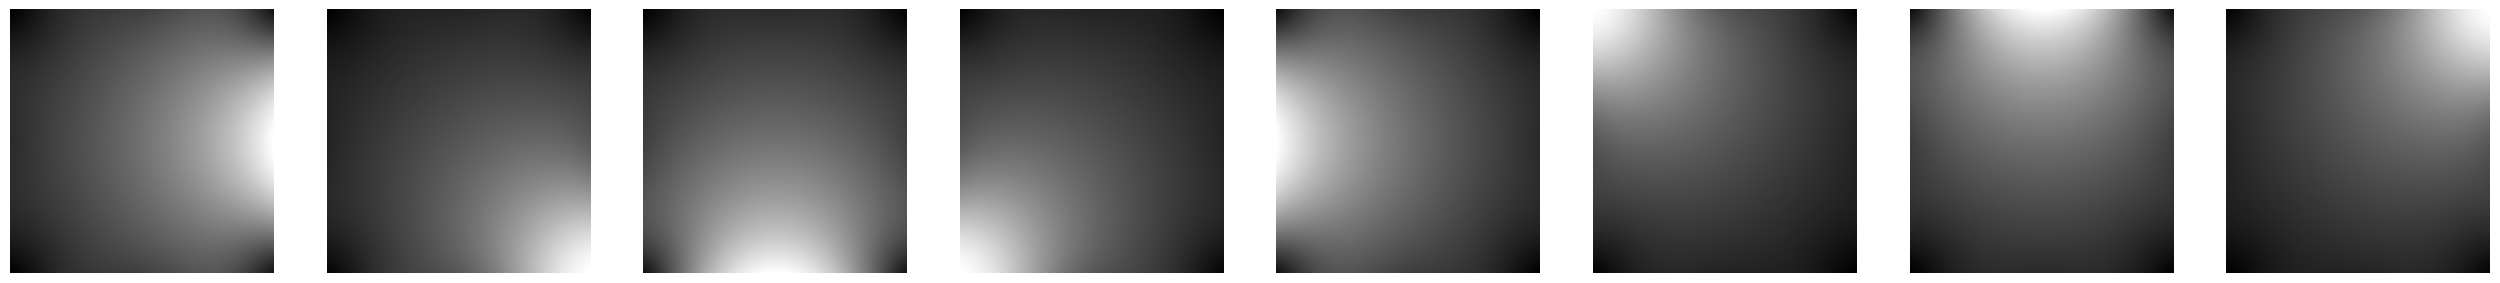

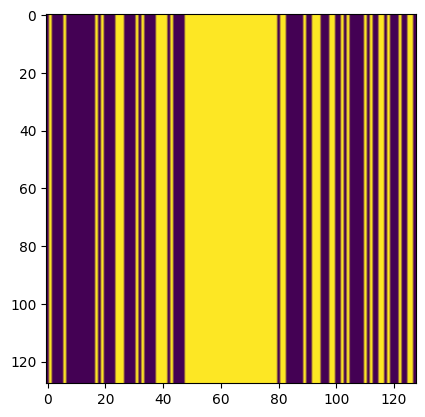

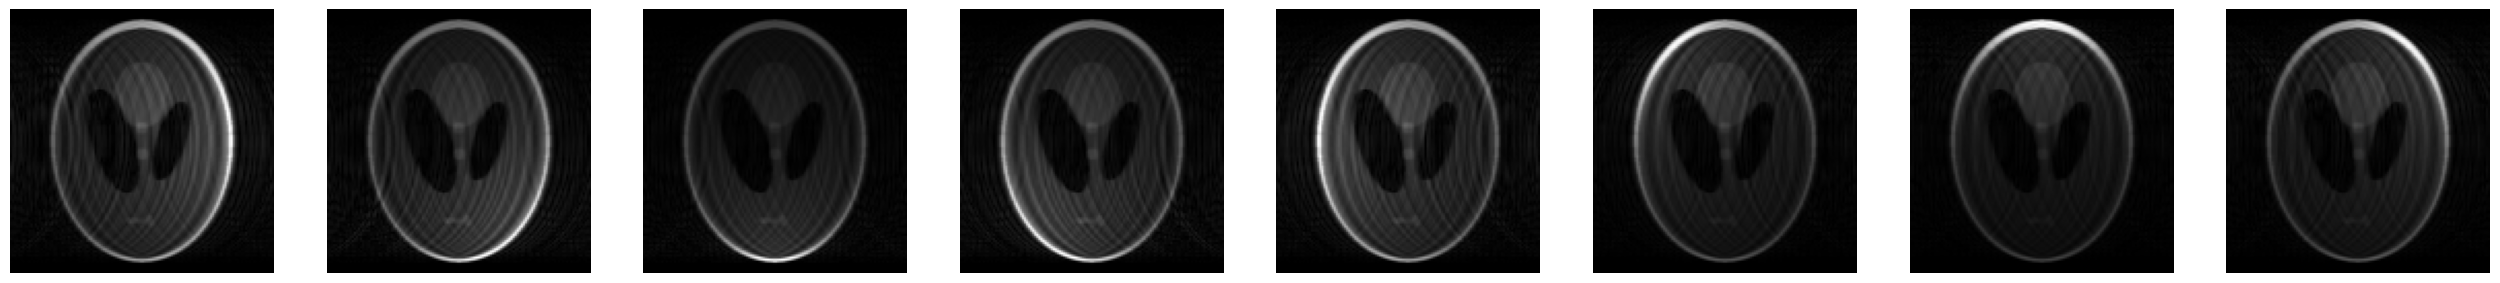

In [423]:
image_gt = init_phantom((SIZE, SIZE))   # Complex tensor, shape (H,W)

# Simulate CSMs
csm = torch.tensor(birdcage_maps((NUM_COILS, SIZE, SIZE), r=1.5, dtype=np.complex64))  # Shape format (C,H,W)
csm = csm / torch.norm(csm, p=2, dim=0, keepdim=True)

# Display CSMs
fig, axs = plt.subplots(1, NUM_COILS, figsize=(NUM_COILS*4, 4))
for c in range(NUM_COILS):
    imshow(torch.abs(csm[c, :, :]), ax=axs[c])
plt.show()

# Simulate multi-coil undersampled data
mask = generate_sampling_mask(tuple(image_gt.shape), 1 / ACCELERATION)
mask = mask.unsqueeze(0)
# mask = torch.repeat_interleave(mask, NUM_COILS, dim=0)
kspace = fft2c(image_gt * csm) * mask # Simulate undersmapling
# kspace = fft2c(image_gt * csm) ##
# kspace = kspace + torch.randn(*kspace.shape) * 0.1 # Simulate nosie

plt.imshow(mask.squeeze()); plt.show()

coil_images = ifft2c(kspace)  # Shape format (C,H,W)
fig, axs = plt.subplots(1, NUM_COILS, figsize=(NUM_COILS*4, 4))
for c in range(NUM_COILS):
    imshow(torch.abs(coil_images[c, :, :]), ax=axs[c])
plt.show()

### Calibration

EspiritCalib: 100%|██████████| 100/100 [00:00<00:00, 561.72it/s]


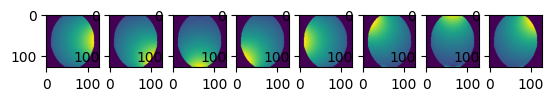

In [448]:
# Baseline
esp_maps = sigpy.mri.app.EspiritCalib(kspace.numpy(), calib_width=24, thresh=0.02, kernel_width=6, crop=0.95).run()

fig, axs = plt.subplots(1,NUM_COILS)
for chan in range(NUM_COILS):
    axs[chan].imshow(np.abs(esp_maps[chan]))
plt.show()

Num kernels: 85
torch.Size([85, 8, 128, 128]) torch.Size([8, 128, 128])
torch.Size([16384, 85, 8])
tensor(9.4530e-05) tensor(0.0278)


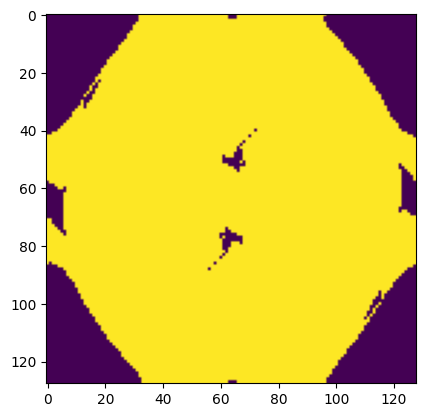

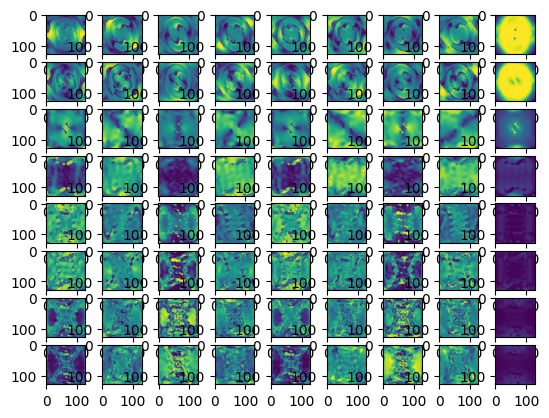

In [466]:
def espirit_calib(kspace, calib_region_size=24, num_csm_components=1):
    
    # Build the Block-Hankel calib matrix
    kernel_size = 6
    ksp_center = SIZE // 2
    A = torch.empty((calib_region_size**2, kernel_size**2 * NUM_COILS)) # Shape (calib_region_size**2, kernel_size**2 * num_coils)
    for i in range(calib_region_size):
        for j in range(calib_region_size):
            row_start = ksp_center - calib_region_size//2 + i
            col_start = ksp_center - calib_region_size//2 + j
            row_end, col_end = row_start + kernel_size, col_start + kernel_size
            calib_matrix_row = kspace[:, row_start:row_end, col_start:col_end].reshape((NUM_COILS, kernel_size**2)).flatten()
            A[calib_region_size*i + j] = calib_matrix_row.clone()

    # SVD to compute V
    U, S, VH = torch.linalg.svd(A, full_matrices=False)
    V = VH.conj().T

    # # DEBUG
    # plt.imshow(A.abs()); plt.show()
    # plt.imshow(V.abs()); plt.show()
    # plt.plot(S); plt.show()


    # Extract V-parallel
    cutoff = 0.02
    num_kernels = S[S/S.max() > cutoff].shape[0]
    V_parallel = V[:, :num_kernels]
    print("Num kernels:", num_kernels)

    # Build Gq matrices for each spatial location q
    kernels = torch.empty((num_kernels, NUM_COILS, kernel_size, kernel_size))
    for k in range(num_kernels):
        for c in range(NUM_COILS):
            offset = c * kernel_size**2 
            kernels[k, c] = V_parallel[ offset : offset + kernel_size**2, k ].reshape((kernel_size, kernel_size)).clone()
    pad_before, pad_after = SIZE//2 - kernel_size//2, SIZE//2 - kernel_size//2
    kernels = torch.nn.functional.pad(kernels, pad=(pad_before, pad_after, pad_before, pad_after, 0, 0, 0, 0), mode='constant', value=0)
    print(kernels.shape, kspace.shape)
    kernel_images = ifft2c(kernels)
    kernel_images = kernel_images * SIZE**2 / kernel_size**2
    Gq = kernel_images.reshape(num_kernels, NUM_COILS, SIZE**2).permute((2,0,1)) # Shape (rows*cols, num_kernels, num_coils)
    print(Gq.shape)


    # Eigendecompose GqH.Gq matrices
    GqHGq = torch.bmm(Gq.conj().permute(0,2,1), Gq) # Shape (rows*cols, num_coils, num_coils)
    # GqHGq = GqHGq * SIZE**2 / kernel_size**2
    eigenvalues, eigenvectors = torch.linalg.eig(GqHGq)
    eigenvalues = eigenvalues.abs()
    eigenvectors = eigenvectors / torch.norm(eigenvectors, p=2, dim=[1], keepdim=True) # Normalize the vectors to unit norm
    print(eigenvalues.min(), eigenvalues.max()) # TODO: All values are way smaller than 1. Should be 1 in foreground. Fix this.
    

    eigenvalue_thresh = 2e-2 # TODO: should be around 0.9
    body_mask = eigenvalues[:,0].reshape((SIZE,SIZE)) > eigenvalue_thresh
    plt.imshow(body_mask); plt.show()
    # plt.hist(eigenvalues[:,0]); plt.show()


    # DEBUG
    # mps *= xp.conj(mps[0] / xp.abs(mps[0]))
    num_components = NUM_COILS
    fig, axs = plt.subplots(num_components,NUM_COILS+1)
    for comp in range(num_components):
        for chan in range(NUM_COILS):
            maps = eigenvectors[:,chan,comp].reshape((SIZE,SIZE))
            axs[comp][chan].imshow(maps.abs())
        axs[comp][chan+1].imshow(eigenvalues[:,comp].reshape((SIZE,SIZE)).abs(), vmax=eigenvalues.max())
    plt.show()


    # Select required CSM omponents. Actual CSM is the dominant component with eigenvalue=1.
    csm_components = []
    for component in range(num_csm_components):
        csm_component = eigenvectors[:,:,component]   # Shape (rows*cols, num_coils)
        csm_component = csm_component.T.reshape(NUM_COILS, SIZE, SIZE) # Shape (num_coils, rows, cols)
        csm_components.append(csm_component)
    return csm_components


csm_components = espirit_calib(kspace, calib_region_size=24, num_csm_components=1)

### Reconstruction

In [ ]:
class SENSEOperator:
    def __init__(self, csm, mask):
        self.csm = csm
        self.mask = mask
    def __call__(self, image):
        return fft2c(self.csm * image) * self.mask
    def H(self, kspace):
        return torch.sum(self.csm.conj() * ifft2c(self.mask * kspace), dim=0)
    
def conjdot(a, b):
    return torch.abs(torch.sum(torch.conj(a) * b))

def cg_sense(kspace, csm, mask, eps=1e-6):
    
    # Linear operators
    E = SENSEOperator(csm, mask)

    # Init state
    a = E.H(kspace)  # (H, W)
    b = torch.zeros_like(a)  # (H, W)
    p = a.clone()          # (H, W)
    r = a.clone()          # (H, W)

    # Precompute
    rdotr_prev = conjdot(r, r)

    # Loop
    while True:

        delta = rdotr_prev / conjdot(a, a)
        if delta < eps:
            break
        
        q = E.H(E(p))
        b += (rdotr_prev / conjdot(p, q)) * p
        r -= (rdotr_prev / conjdot(p, q)) * q
        rdotr = conjdot(r, r)
        p = r + (rdotr / rdotr_prev) * p
        
        rdotr_prev = rdotr

    return b

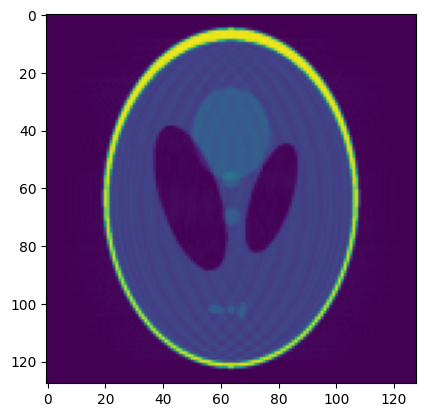

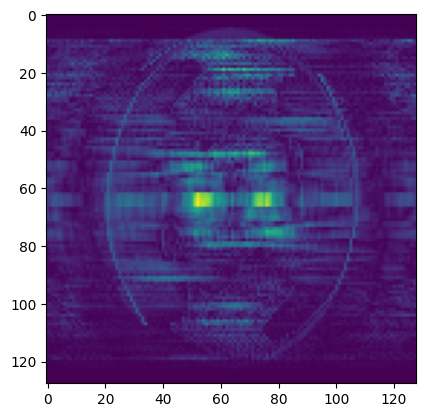

In [433]:

# SENSE recon with original CSMs
image_recon = cg_sense(kspace, csm, mask, eps=1e-10)
plt.imshow(image_recon.abs()); plt.show()

# SENSE recon with ESPIRiT CSMs
espirit_csm = csm_components[0]
image_recon = cg_sense(kspace, espirit_csm, mask, eps=1e-10)
plt.imshow(image_recon.abs()); plt.show()

